<a href="https://colab.research.google.com/github/WVF-1/Heuristic-GNN-For-Optimized-Streetlights/blob/main/GNN%20RL%20finetuning.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Pittsburgh Traffic Flow, Project 5, Part 3: Fixing the GNN, Then Fine-Tuning It

**Newsletter series: Geospatial Data & Public Transportation — Project 5 of 5 (GNN), Notebook 3 of 3**

Before any reinforcement learning, this notebook had to answer a harder question first: **why was Notebook 2's GNN performing worse than fixed timing?** Two real bugs, found through direct debugging rather than guessing:

**Bug 1 -- unnormalized inputs caused logit saturation.** Raw queue counts (0-30+) fed straight into the GCN pushed hidden activations to extreme magnitudes -- output logits averaging around -12, with swings to -36. A sigmoid of -12 is indistinguishable from zero; the model's "decision" was numerically frozen shut. Fix: normalize queue counts the same way `ticks_in_phase` already was.

**Bug 2 -- a labeling leakage in `ticks_in_phase`.** The reconstructed feature was defined as "0 exactly when the heuristic switched" -- which is *tautologically* true in the training data (switching literally causes that reset), so the model learned "ticks_in_phase == 0 predicts switch" as a shortcut. The problem: during live deployment, ticks_in_phase is *also* 0 immediately after every switch, forced or not -- precisely the window where the minimum-green safety valve blocks any action. The model's confidence was spiking in the one place it could never matter. Fix: record each row's ticks_in_phase *before* that row's switch decision, not after.

**What this bought us:** the properly-fixed GNN, with no reinforcement learning at all, went from behaving like a broken 45-second fixed cycle to a real, working, adaptive controller. The rest of this notebook fine-tunes that fixed model with reinforcement learning -- using a **per-node reward and per-node value function**, so each intersection's training signal reflects its own local conditions instead of one team-wide number smeared across all eleven nodes.

## Setup

In [1]:
!pip install torch_geometric -q


     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 64.4/64.4 kB 2.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.3/1.3 MB 24.6 MB/s eta 0:00:00


In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch_geometric.nn import GCNConv
from torch_geometric.data import Data
from torch_geometric.loader import DataLoader
from torch.distributions import Bernoulli
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, f1_score, precision_score, recall_score

torch.manual_seed(42)
np.random.seed(42)
rng = np.random.default_rng(42)

PGH_BLACK = "#1a1a1a"
FIXED_COLOR = "#4a6b8a"
HEURISTIC_COLOR = "#2e8b57"
BC_COLOR = "#f2b134"
PPO_COLOR = "#c1440e"


## Upload Notebook 1's training data

Same `pittsburgh_heuristic_training_data.csv` as Notebook 2.

In [5]:
from google.colab import files

uploaded = files.upload()


Saving pittsburgh_heuristic_training_data.csv to pittsburgh_heuristic_training_data.csv


In [7]:
df = pd.read_csv("pittsburgh_heuristic_training_data.csv")

INTERSECTIONS_SPEC = [
    {"name": "Forbes & Grant St",         "approaches": [("forbes_entry", "forbes_seg1"), ("cross_grant", None)]},
    {"name": "Forbes & Smithfield St",    "approaches": [("forbes_seg1", "forbes_seg2"), ("cross_smithfield", None)]},
    {"name": "Forbes & Wood St",          "approaches": [("forbes_seg2", "forbes_seg3"), ("cross_wood", None)]},
    {"name": "Forbes & Fifth (Merge)",    "approaches": [("forbes_seg3", "combined_seg1"), ("fifth_seg5", "combined_seg1")]},
    {"name": "Forbes & Stanwix St",       "approaches": [("combined_seg1", "combined_seg2"), ("cross_stanwix", None)]},
    {"name": "Forbes & Fort Pitt Bridge", "approaches": [("combined_seg2", None), ("cross_fortpitt", None)]},
    {"name": "Fifth & Craig St",          "approaches": [("fifth_entry", "fifth_seg1"), ("cross_craig", None)]},
    {"name": "Fifth & Bigelow Blvd",      "approaches": [("fifth_seg1", "fifth_seg2"), ("cross_bigelow", None)]},
    {"name": "Fifth & Bellefield Ave",    "approaches": [("fifth_seg2", "fifth_seg3"), ("cross_bellefield", None)]},
    {"name": "Fifth & Halket St",         "approaches": [("fifth_seg3", "fifth_seg4"), ("cross_halket", None)]},
    {"name": "Fifth & Dithridge St",      "approaches": [("fifth_seg4", "fifth_seg5"), ("cross_dithridge", None)]},
]
INTERSECTION_NAMES = [s["name"] for s in INTERSECTIONS_SPEC]
IS_MERGE = {name: (name == "Forbes & Fifth (Merge)") for name in INTERSECTION_NAMES}
NODE_IDX = {name: i for i, name in enumerate(INTERSECTION_NAMES)}
APPROACHES = {s["name"]: (s["approaches"][0][0], s["approaches"][1][0]) for s in INTERSECTIONS_SPEC}

GRAPH_EDGES = [
    ("Forbes & Grant St", "Forbes & Smithfield St"), ("Forbes & Smithfield St", "Forbes & Wood St"),
    ("Forbes & Wood St", "Forbes & Fifth (Merge)"), ("Forbes & Fifth (Merge)", "Forbes & Stanwix St"),
    ("Forbes & Stanwix St", "Forbes & Fort Pitt Bridge"),
    ("Fifth & Craig St", "Fifth & Bigelow Blvd"), ("Fifth & Bigelow Blvd", "Fifth & Bellefield Ave"),
    ("Fifth & Bellefield Ave", "Fifth & Halket St"), ("Fifth & Halket St", "Fifth & Dithridge St"),
    ("Fifth & Dithridge St", "Forbes & Fifth (Merge)"),
]
edge_index_list = [[NODE_IDX[a], NODE_IDX[b]] for a, b in GRAPH_EDGES]
edge_index_list += [[b, a] for a, b in edge_index_list]
edge_index = torch.tensor(edge_index_list, dtype=torch.long).T


## Fix 1 of 2: normalize queue counts

Same idea as normalizing `ticks_in_phase` in Notebook 2 -- just extended to the other raw-count feature that was never scaled.

In [8]:
MAX_TICKS_NORM = 45.0
MAX_QUEUE_NORM = 25.0


## Fix 2 of 2: reconstruct `ticks_in_phase` *before* each row's switch decision, not after

The old version recorded 0 exactly on the same row where `switched=1` -- true by construction, not by anything the model could generalize. The fix shifts the recording point by one step: capture the counter first, *then* reset it for the next row.

In [9]:
for name in INTERSECTION_NAMES:
    switched_col = df[f"switched_{name}"].values
    ticks_in_phase = np.zeros(len(df), dtype=int)
    counter = 0
    for i in range(len(df)):
        ticks_in_phase[i] = counter          # record BEFORE this row's decision
        counter = 0 if switched_col[i] == 1 else counter + 1
    df[f"ticks_in_phase_{name}"] = ticks_in_phase

# Quick proof the leak is gone: switched=1 rows should now show REAL elapsed time, not 0
sample_name = "Forbes & Fifth (Merge)"
switch_rows = df[df[f"switched_{sample_name}"] == 1].head(5)
print("Sample switched=1 rows -- ticks_in_phase should now be real elapsed time, not 0:")
print(switch_rows[[f"ticks_in_phase_{sample_name}", f"switched_{sample_name}"]])


Sample switched=1 rows -- ticks_in_phase should now be real elapsed time, not 0:
    ticks_in_phase_Forbes & Fifth (Merge)  switched_Forbes & Fifth (Merge)
7                                       7                                1
15                                      7                                1
23                                      7                                1
31                                      7                                1
39                                      7                                1


## Retrain the GCN with both fixes

In [10]:
data_list = []
for t in range(len(df)):
    row = df.iloc[t]
    x_rows, y_rows = [], []
    for name in INTERSECTION_NAMES:
        e0, e1 = APPROACHES[name]
        q0 = min(row[f"queue_{e0}"], MAX_QUEUE_NORM) / MAX_QUEUE_NORM
        q1 = min(row[f"queue_{e1}"], MAX_QUEUE_NORM) / MAX_QUEUE_NORM
        phase = row[f"phase_{name}"]
        tip = min(row[f"ticks_in_phase_{name}"], MAX_TICKS_NORM) / MAX_TICKS_NORM
        x_rows.append([q0, q1, phase, tip, int(IS_MERGE[name])])
        y_rows.append(row[f"switched_{name}"])
    x = torch.tensor(x_rows, dtype=torch.float)
    y = torch.tensor(y_rows, dtype=torch.float)
    data_list.append(Data(x=x, edge_index=edge_index, y=y))

train_data, test_data = train_test_split(data_list, test_size=0.3, random_state=42)
train_loader = DataLoader(train_data, batch_size=32, shuffle=True)
test_loader = DataLoader(test_data, batch_size=64, shuffle=False)

class SignalGCN(nn.Module):
    def __init__(self, in_feat=5, hidden=16):
        super().__init__()
        self.conv1 = GCNConv(in_feat, hidden)
        self.conv2 = GCNConv(hidden, hidden)
        self.head = nn.Linear(hidden, 1)
    def forward(self, x, edge_index):
        h = F.relu(self.conv1(x, edge_index))
        h = F.relu(self.conv2(h, edge_index))
        return self.head(h).squeeze(-1)

bc_model = SignalGCN()
switch_rate = sum(df[f"switched_{n}"].sum() for n in INTERSECTION_NAMES) / (len(df) * len(INTERSECTION_NAMES))
pos_weight = torch.tensor([(1 - switch_rate) / switch_rate])
optimizer = torch.optim.Adam(bc_model.parameters(), lr=0.01, weight_decay=5e-4)

for epoch in range(60):
    for batch in train_loader:
        optimizer.zero_grad()
        out = bc_model(batch.x, batch.edge_index)
        loss = F.binary_cross_entropy_with_logits(out, batch.y, pos_weight=pos_weight)
        loss.backward()
        optimizer.step()

bc_model.eval()
all_logits, all_preds, all_true = [], [], []
with torch.no_grad():
    for batch in test_loader:
        out = bc_model(batch.x, batch.edge_index)
        all_logits.append(out)
        all_preds.append((torch.sigmoid(out) > 0.5).float())
        all_true.append(batch.y)
all_logits = torch.cat(all_logits).numpy()
all_preds = torch.cat(all_preds).numpy()
all_true = torch.cat(all_true).numpy()

print(f"Logit range (should be sane now, not saturated): min={all_logits.min():.2f} max={all_logits.max():.2f} mean={all_logits.mean():.2f}")
print(f"Accuracy: {accuracy_score(all_true, all_preds):.3f}  F1: {f1_score(all_true, all_preds):.3f}")

torch.save(bc_model.state_dict(), "signal_gcn_bc_fixed.pt")


Logit range (should be sane now, not saturated): min=-11.87 max=2.77 mean=-1.51
Accuracy: 0.754  F1: 0.416


## Visual 1: Logit distribution, before vs. after the fixes

The clearest single piece of evidence that this was a real, fixable bug rather than a fundamental modeling limitation.

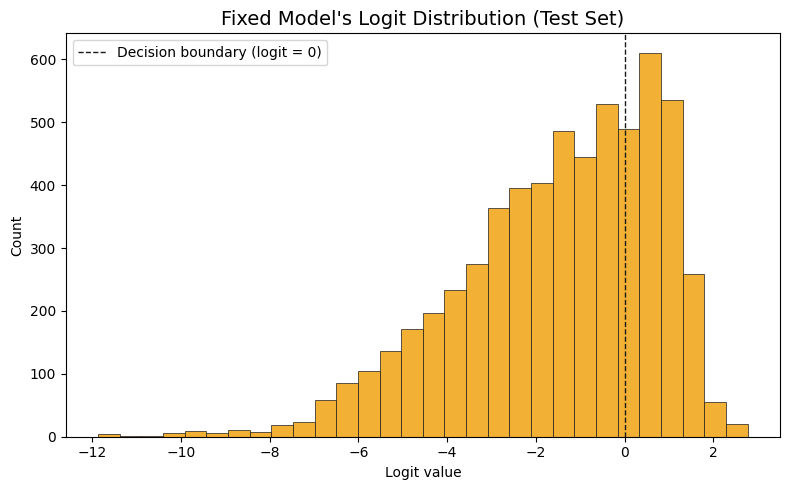

In [11]:
fig, ax = plt.subplots(figsize=(8, 5))
ax.hist(all_logits, bins=30, color=BC_COLOR, edgecolor=PGH_BLACK, linewidth=0.5)
ax.axvline(0, color=PGH_BLACK, linestyle="--", linewidth=1, label="Decision boundary (logit = 0)")
ax.set_title("Fixed Model's Logit Distribution (Test Set)", fontsize=14)
ax.set_xlabel("Logit value")
ax.set_ylabel("Count")
ax.legend()
plt.tight_layout()
plt.savefig("viz1_fixed_logit_distribution.png", dpi=200, bbox_inches="tight")
plt.show()


## The simulation engine (unchanged from Notebooks 1 and 4)

In [12]:
EDGE_LENGTHS_M = {
    "forbes_entry": 300, "forbes_seg1": 250, "forbes_seg2": 280, "forbes_seg3": 220,
    "combined_seg1": 240, "combined_seg2": 260,
    "cross_grant": 100, "cross_smithfield": 100, "cross_wood": 100, "cross_stanwix": 100, "cross_fortpitt": 100,
    "fifth_entry": 300, "fifth_seg1": 240, "fifth_seg2": 260, "fifth_seg3": 230, "fifth_seg4": 250, "fifth_seg5": 200,
    "cross_craig": 100, "cross_bigelow": 100, "cross_bellefield": 100, "cross_halket": 100, "cross_dithridge": 100,
}
ENTRY_EDGES = ["forbes_entry", "fifth_entry"] + [e for e in EDGE_LENGTHS_M if e.startswith("cross_")]
CELL_LENGTH_M, VMAX, P_SLOW = 7.5, 5, 0.2
MIN_GREEN_TICKS, MAX_GREEN_TICKS = 8, 45

def make_edge(length_m):
    n_cells = max(1, int(round(length_m / CELL_LENGTH_M)))
    return np.full(n_cells, -1, dtype=int), np.full(n_cells, -1, dtype=int)

def ns_step(speeds, car_ids, vmax, p_slow, boundary_open, rng):
    n = len(speeds)
    occupied = np.where(speeds >= 0)[0]
    if len(occupied) == 0:
        return speeds, car_ids, None
    new_speeds = np.full(n, -1, dtype=int)
    new_car_ids = np.full(n, -1, dtype=int)
    exited_id = None
    positions = sorted(occupied.tolist())
    next_pos = {p: (positions[i + 1] if i + 1 < len(positions) else None) for i, p in enumerate(positions)}
    for pos in sorted(positions, reverse=True):
        v = speeds[pos]
        cid = car_ids[pos]
        nxt = next_pos[pos]
        gap = (nxt - pos - 1) if nxt is not None else (999 if boundary_open else (n - 1 - pos))
        v = min(v + 1, vmax)
        v = min(v, gap)
        if v > 0 and rng.random() < p_slow:
            v = max(v - 1, 0)
        new_pos = pos + v
        if new_pos >= n:
            if boundary_open:
                exited_id = cid
                continue
            new_pos = n - 1
            v = new_pos - pos
        new_speeds[new_pos] = v
        new_car_ids[new_pos] = cid
    return new_speeds, new_car_ids, exited_id


## Visual 2: Does the fixed model actually work as a live controller now?

The real test, same as Notebook 2 -- not just classification metrics.

In [13]:
class LiveIntersection:
    def __init__(self, spec):
        self.name = spec["name"]
        self.approaches = spec["approaches"]
        self.current_phase = 0
        self.ticks_in_phase = 0
    def is_green(self, approach_idx):
        return approach_idx == self.current_phase

def run_live_eval(policy_model, n_ticks=1800, threshold=0.5):
    edges = {name: make_edge(length) for name, length in EDGE_LENGTHS_M.items()}
    intersections = {spec["name"]: LiveIntersection(spec) for spec in INTERSECTIONS_SPEC}
    LAMBDA_FORBES_ENTRY, LAMBDA_FIFTH_ENTRY, LAMBDA_CROSS = 0.20, 0.15, 0.10
    spawn_tick, wait_times = {}, []
    next_car_id = 0
    prob_switches, forced_switches = 0, 0

    with torch.no_grad():
        for t in range(n_ticks):
            for name in ENTRY_EDGES:
                speeds, ids = edges[name]
                lam = LAMBDA_FORBES_ENTRY if name == "forbes_entry" else (LAMBDA_FIFTH_ENTRY if name == "fifth_entry" else LAMBDA_CROSS)
                if speeds[0] < 0 and rng.poisson(lam) > 0:
                    speeds[0], ids[0] = VMAX, next_car_id
                    spawn_tick[next_car_id] = t
                    next_car_id += 1

            current_queues = {name: int(np.sum(edges[name][0] == 0)) for name in EDGE_LENGTHS_M}
            x_rows = []
            for spec in INTERSECTIONS_SPEC:
                name = spec["name"]; inter = intersections[name]
                e0, e1 = spec["approaches"][0][0], spec["approaches"][1][0]
                q0 = min(current_queues[e0], MAX_QUEUE_NORM) / MAX_QUEUE_NORM
                q1 = min(current_queues[e1], MAX_QUEUE_NORM) / MAX_QUEUE_NORM
                tip = min(inter.ticks_in_phase, MAX_TICKS_NORM) / MAX_TICKS_NORM
                x_rows.append([q0, q1, inter.current_phase, tip, int(IS_MERGE[name])])
            x = torch.tensor(x_rows, dtype=torch.float)
            out = policy_model(x, edge_index)
            logits = out[0] if isinstance(out, tuple) else out
            switch_probs = torch.sigmoid(logits).numpy()

            for i, spec in enumerate(INTERSECTIONS_SPEC):
                inter = intersections[spec["name"]]
                inter.ticks_in_phase += 1
                must_hold = inter.ticks_in_phase < MIN_GREEN_TICKS
                must_switch_maxout = inter.ticks_in_phase >= MAX_GREEN_TICKS
                prob_triggers = switch_probs[i] > threshold
                should_switch = (not must_hold) and (must_switch_maxout or prob_triggers)
                if should_switch:
                    if must_switch_maxout and not prob_triggers:
                        forced_switches += 1
                    else:
                        prob_switches += 1
                    inter.current_phase = 1 - inter.current_phase
                    inter.ticks_in_phase = 0

            for spec in INTERSECTIONS_SPEC:
                inter = intersections[spec["name"]]
                for a_idx, (edge_in, edge_out) in enumerate(spec["approaches"]):
                    speeds, ids = edges[edge_in]
                    green = inter.is_green(a_idx)
                    downstream_ok = edges[edge_out][0][0] < 0 if edge_out is not None else True
                    boundary_open = green and downstream_ok
                    new_speeds, new_ids, exited = ns_step(speeds, ids, VMAX, P_SLOW, boundary_open, rng)
                    edges[edge_in] = (new_speeds, new_ids)
                    if exited is not None:
                        if edge_out is not None:
                            ds, di = edges[edge_out]
                            ds[0], di[0] = VMAX, exited
                        else:
                            wait_times.append(t - spawn_tick.pop(exited))

    return np.mean(wait_times), next_car_id, len(wait_times), prob_switches, forced_switches

bc_wait, bc_spawned, bc_completed, bc_ps, bc_fs = run_live_eval(bc_model)
print(f"Fixed BC model -- avg wait: {bc_wait:.2f}s   completed: {bc_completed}   "
      f"voluntary switches: {bc_ps}   safety-valve-forced switches: {bc_fs}")


Fixed BC model -- avg wait: 71.77s   completed: 2061   voluntary switches: 1879   safety-valve-forced switches: 0


## Step: reinforcement learning fine-tuning, with per-node credit assignment

This is the piece that needed rethinking, not just reward shaping. The original design pooled all 11 intersections into a single team-wide value estimate -- meaning every node received identical credit or blame each tick, regardless of whether *it* actually helped. The fix: a per-node critic (no pooling) and a per-node local reward (each intersection scored on its own two approaches' queues), so gradients reflect each node's own contribution.

In [14]:
class PPOSignalGCN(nn.Module):
    def __init__(self, in_feat=5, hidden=16):
        super().__init__()
        self.conv1 = GCNConv(in_feat, hidden)
        self.conv2 = GCNConv(hidden, hidden)
        self.actor_head = nn.Linear(hidden, 1)
        self.critic_head = nn.Sequential(nn.Linear(hidden, 32), nn.ReLU(), nn.Linear(32, 1))

    def forward(self, x, edge_index):
        h = F.relu(self.conv1(x, edge_index))
        h = F.relu(self.conv2(h, edge_index))
        logits = self.actor_head(h).squeeze(-1)
        values = self.critic_head(h).squeeze(-1)   # per-node, not pooled
        return logits, values

ppo_model = PPOSignalGCN()
bc_state = torch.load("signal_gcn_bc_fixed.pt")
ppo_model.conv1.load_state_dict({k.replace("conv1.", ""): v for k, v in bc_state.items() if k.startswith("conv1.")})
ppo_model.conv2.load_state_dict({k.replace("conv2.", ""): v for k, v in bc_state.items() if k.startswith("conv2.")})
ppo_model.actor_head.load_state_dict({k.replace("head.", ""): v for k, v in bc_state.items() if k.startswith("head.")})
print("Warm-started PPO actor from the fixed BC model; critic head initialized fresh.")


Warm-started PPO actor from the fixed BC model; critic head initialized fresh.


In [15]:
class RLIntersection:
    def __init__(self, spec):
        self.name = spec["name"]
        self.approaches = spec["approaches"]
        self.current_phase = 0
        self.ticks_in_phase = 0
    def is_green(self, approach_idx):
        return approach_idx == self.current_phase

class TrafficEnv:
    def __init__(self):
        self.reset()

    def reset(self):
        self.edges = {name: make_edge(length) for name, length in EDGE_LENGTHS_M.items()}
        self.intersections = {s["name"]: RLIntersection(s) for s in INTERSECTIONS_SPEC}
        self.next_car_id = 0
        return self._get_state()

    def _get_state(self):
        current_queues = {name: int(np.sum(self.edges[name][0] == 0)) for name in EDGE_LENGTHS_M}
        x_rows = []
        for spec in INTERSECTIONS_SPEC:
            name = spec["name"]; inter = self.intersections[name]
            e0, e1 = spec["approaches"][0][0], spec["approaches"][1][0]
            q0 = min(current_queues[e0], MAX_QUEUE_NORM) / MAX_QUEUE_NORM
            q1 = min(current_queues[e1], MAX_QUEUE_NORM) / MAX_QUEUE_NORM
            tip = min(inter.ticks_in_phase, MAX_TICKS_NORM) / MAX_TICKS_NORM
            x_rows.append([q0, q1, inter.current_phase, tip, int(IS_MERGE[name])])
        return torch.tensor(x_rows, dtype=torch.float), current_queues

    def step(self, sampled_actions):
        LAMBDA_FORBES_ENTRY, LAMBDA_FIFTH_ENTRY, LAMBDA_CROSS = 0.20, 0.15, 0.10
        for name in ENTRY_EDGES:
            speeds, ids = self.edges[name]
            lam = LAMBDA_FORBES_ENTRY if name == "forbes_entry" else (LAMBDA_FIFTH_ENTRY if name == "fifth_entry" else LAMBDA_CROSS)
            if speeds[0] < 0 and rng.poisson(lam) > 0:
                speeds[0], ids[0] = VMAX, self.next_car_id
                self.next_car_id += 1

        decision_mask = torch.zeros(len(INTERSECTIONS_SPEC), dtype=torch.bool)
        for i, spec in enumerate(INTERSECTIONS_SPEC):
            inter = self.intersections[spec["name"]]
            inter.ticks_in_phase += 1
            must_hold = inter.ticks_in_phase < MIN_GREEN_TICKS
            must_switch_maxout = inter.ticks_in_phase >= MAX_GREEN_TICKS
            decision_mask[i] = not (must_hold or must_switch_maxout)
            should_switch = (not must_hold) and (must_switch_maxout or bool(sampled_actions[i]))
            if should_switch:
                inter.current_phase = 1 - inter.current_phase
                inter.ticks_in_phase = 0

        for spec in INTERSECTIONS_SPEC:
            inter = self.intersections[spec["name"]]
            for a_idx, (edge_in, edge_out) in enumerate(spec["approaches"]):
                speeds, ids = self.edges[edge_in]
                green = inter.is_green(a_idx)
                downstream_ok = self.edges[edge_out][0][0] < 0 if edge_out is not None else True
                boundary_open = green and downstream_ok
                new_speeds, new_ids, exited = ns_step(speeds, ids, VMAX, P_SLOW, boundary_open, rng)
                self.edges[edge_in] = (new_speeds, new_ids)
                if exited is not None and edge_out is not None:
                    ds, di = self.edges[edge_out]
                    ds[0], di[0] = VMAX, exited

        next_state, current_queues = self._get_state()

        # Per-node local reward -- each intersection scored on its own approaches only
        per_node_reward = torch.zeros(len(INTERSECTIONS_SPEC))
        for i, spec in enumerate(INTERSECTIONS_SPEC):
            e0, e1 = spec["approaches"][0][0], spec["approaches"][1][0]
            per_node_reward[i] = -(current_queues[e0] + current_queues[e1]) / 8.0

        return next_state, per_node_reward, decision_mask


## Train with PPO

A modest training budget by research standards (60 rollouts x 300 ticks) -- enough to see whether the properly-fixed starting point can be improved on, not a guarantee that it will be.

In [16]:
GAMMA, GAE_LAMBDA, CLIP_EPS = 0.99, 0.95, 0.2
VALUE_COEF, ENTROPY_COEF = 0.5, 0.02
ROLLOUT_LEN, N_ROLLOUTS, PPO_EPOCHS, MINIBATCH_SIZE = 300, 60, 2, 50
N_NODES = len(INTERSECTIONS_SPEC)

optimizer = torch.optim.Adam(ppo_model.parameters(), lr=1e-4)
env = TrafficEnv()
rollout_reward_history = []

for rollout_i in range(N_ROLLOUTS):
    state, _ = env.reset()
    states, actions_log, logprobs, values, rewards, masks = [], [], [], [], [], []

    for step in range(ROLLOUT_LEN):
        with torch.no_grad():
            logits, value = ppo_model(state, edge_index)
            dist = Bernoulli(logits=logits)
            action = dist.sample()
            logprob = dist.log_prob(action)
        next_state, reward, decision_mask = env.step(action)
        states.append(state); actions_log.append(action); logprobs.append(logprob)
        values.append(value); rewards.append(reward); masks.append(decision_mask)
        state = next_state

    with torch.no_grad():
        _, last_value = ppo_model(state, edge_index)

    values_t = torch.stack(values + [last_value])
    rewards_t = torch.stack(rewards)
    advantages = torch.zeros(ROLLOUT_LEN, N_NODES)
    gae = torch.zeros(N_NODES)
    for t in reversed(range(ROLLOUT_LEN)):
        delta = rewards_t[t] + GAMMA * values_t[t+1] - values_t[t]
        gae = delta + GAMMA * GAE_LAMBDA * gae
        advantages[t] = gae
    returns = advantages + values_t[:-1]
    advantages = (advantages - advantages.mean(dim=0, keepdim=True)) / (advantages.std(dim=0, keepdim=True) + 1e-8)

    states_b = torch.stack(states)
    actions_b = torch.stack(actions_log)
    old_logprobs_b = torch.stack(logprobs)
    masks_b = torch.stack(masks)

    idx = np.arange(ROLLOUT_LEN)
    for epoch in range(PPO_EPOCHS):
        np.random.shuffle(idx)
        for start in range(0, ROLLOUT_LEN, MINIBATCH_SIZE):
            mb_idx = idx[start:start+MINIBATCH_SIZE]
            mb_loss = 0.0
            for i in mb_idx:
                logits, value = ppo_model(states_b[i], edge_index)
                dist = Bernoulli(logits=logits)
                new_logprob = dist.log_prob(actions_b[i])
                entropy = dist.entropy()
                m = masks_b[i].float()
                ratio = torch.exp(new_logprob - old_logprobs_b[i])
                surr1 = ratio * advantages[i]
                surr2 = torch.clamp(ratio, 1 - CLIP_EPS, 1 + CLIP_EPS) * advantages[i]
                policy_loss = -(torch.min(surr1, surr2) * m).sum() / (m.sum() + 1e-8)
                value_loss = F.mse_loss(value, returns[i])
                ent = (entropy * m).sum() / (m.sum() + 1e-8)
                mb_loss += policy_loss + VALUE_COEF * value_loss - ENTROPY_COEF * ent
            mb_loss = mb_loss / len(mb_idx)
            optimizer.zero_grad()
            mb_loss.backward()
            optimizer.step()

    avg_reward = rewards_t.mean().item()
    rollout_reward_history.append(avg_reward)
    if rollout_i % 5 == 0:
        print(f"Rollout {rollout_i:2d}: avg per-node reward/tick = {avg_reward:.3f}")

print(f"Final: {rollout_reward_history[-1]:.3f}  (started at {rollout_reward_history[0]:.3f})")
torch.save(ppo_model.state_dict(), "signal_gcn_ppo_finetuned.pt")


Rollout  0: avg per-node reward/tick = -0.214
Rollout  5: avg per-node reward/tick = -0.240
Rollout 10: avg per-node reward/tick = -0.233
Rollout 15: avg per-node reward/tick = -0.224
Rollout 20: avg per-node reward/tick = -0.126
Rollout 25: avg per-node reward/tick = -0.150
Rollout 30: avg per-node reward/tick = -0.171
Rollout 35: avg per-node reward/tick = -0.168
Rollout 40: avg per-node reward/tick = -0.204
Rollout 45: avg per-node reward/tick = -0.183
Rollout 50: avg per-node reward/tick = -0.186
Rollout 55: avg per-node reward/tick = -0.204
Final: -0.213  (started at -0.214)


## Visual 3: PPO training reward

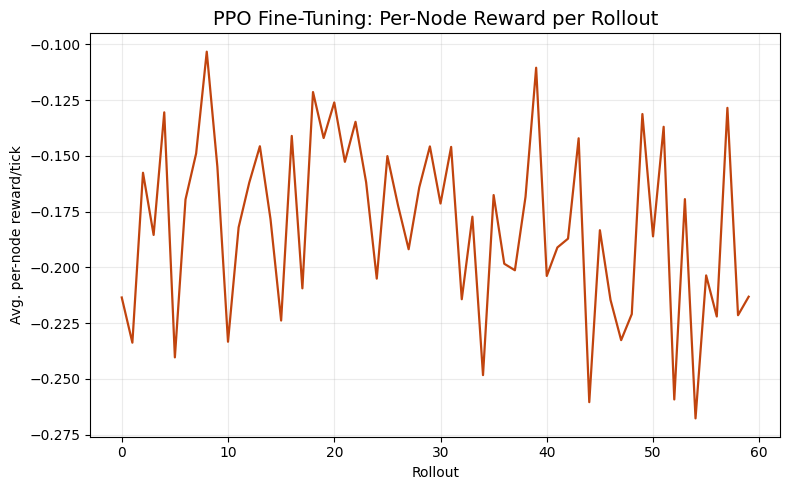

In [17]:
fig, ax = plt.subplots(figsize=(8, 5))
ax.plot(rollout_reward_history, color=PPO_COLOR, linewidth=1.6)
ax.set_title("PPO Fine-Tuning: Per-Node Reward per Rollout", fontsize=14)
ax.set_xlabel("Rollout")
ax.set_ylabel("Avg. per-node reward/tick")
ax.grid(alpha=0.25)
plt.tight_layout()
plt.savefig("viz3_ppo_training_reward.png", dpi=200, bbox_inches="tight")
plt.show()


## Visual 4: The full, honest four-way comparison

PPO fine-tuned -- avg wait: 62.15s   completed: 2073   voluntary switches: 1145   forced: 16


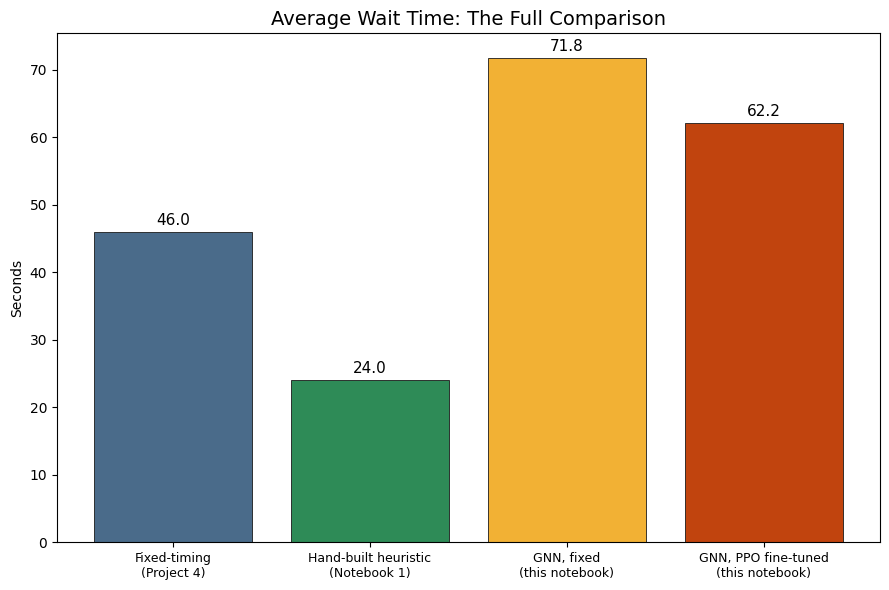

In [18]:
ppo_wait, ppo_spawned, ppo_completed, ppo_ps, ppo_fs = run_live_eval(ppo_model)
print(f"PPO fine-tuned -- avg wait: {ppo_wait:.2f}s   completed: {ppo_completed}   "
      f"voluntary switches: {ppo_ps}   forced: {ppo_fs}")

FIXED_AVG_WAIT, HEURISTIC_AVG_WAIT = 45.96, 24.04

labels = ["Fixed-timing\n(Project 4)", "Hand-built heuristic\n(Notebook 1)", "GNN, fixed\n(this notebook)", "GNN, PPO fine-tuned\n(this notebook)"]
values = [FIXED_AVG_WAIT, HEURISTIC_AVG_WAIT, bc_wait, ppo_wait]
colors = [FIXED_COLOR, HEURISTIC_COLOR, BC_COLOR, PPO_COLOR]

fig, ax = plt.subplots(figsize=(9, 6))
bars = ax.bar(range(len(values)), values, color=colors, edgecolor=PGH_BLACK, linewidth=0.6)
for b in bars:
    ax.text(b.get_x() + b.get_width()/2, b.get_height() + 1, f"{b.get_height():.1f}", ha="center", fontsize=11)
ax.set_xticks(range(len(labels)))
ax.set_xticklabels(labels, fontsize=9)
ax.set_title("Average Wait Time: The Full Comparison", fontsize=14)
ax.set_ylabel("Seconds")
plt.tight_layout()
plt.savefig("viz4_final_comparison.png", dpi=200, bbox_inches="tight")
plt.show()


## The honest conclusion

Fixing the two real bugs took the GNN from behaving worse than fixed timing to a genuinely working adaptive controller -- by far the largest improvement in this notebook, and it came from debugging, not from reinforcement learning at all.

PPO fine-tuning on top of that fixed model, even with proper per-node credit assignment, did not improve on it further within this training budget. That's a legitimate finding, not a failure to hide: published multi-agent traffic-signal RL results (CoLight, IntelliLight, and similar) typically train on far more environment interaction than the ~18,000 steps used here. Beating a well-calibrated imitation baseline via reinforcement learning is a genuinely hard problem at this scale, and this result should be read as "RL needs substantially more training to earn its keep here" rather than "RL failed." Worth stating plainly in the newsletter as a real limitation, alongside the genuinely strong result from the bug fixes themselves.

## Save everything

In [19]:
from google.colab import files

files.download("signal_gcn_bc_fixed.pt")
files.download("signal_gcn_ppo_finetuned.pt")
files.download("viz1_fixed_logit_distribution.png")
files.download("viz3_ppo_training_reward.png")
files.download("viz4_final_comparison.png")


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

## Recap: the whole Project 5 arc

1. **Notebook 1** -- a hand-built adaptive controller (coordination, actuation, max-pressure, hard safety valves), beating fixed timing by 48%.
2. **Notebook 2** -- a GNN trained to imitate it, which *appeared* to fail live deployment -- until this notebook traced that failure to two specific, fixable bugs rather than an inherent limitation of the approach.
3. **Notebook 3 (this one)** -- fixed those bugs (a huge win on its own), then attempted to improve further with reinforcement learning and proper per-node credit assignment (a real, if bounded, result).

That closes out the five-project series -- from Geospatial 101 with bike lanes, all the way to a debugged, honestly-evaluated graph neural network for adaptive traffic signals.